# Results for ArXiv dataset

In [7]:
import os, glob, sys, time
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.extend([parent_dir])

In [ ]:
OUTDIR = os.path.join(parent_dir,"arxiv_outputs")
PATTERN = "arxiv_outputs_*.npz"


# ---------- load all runs ----------
files = sorted(glob.glob(os.path.join(OUTDIR, PATTERN)))
runs = []
for f1 in files:
    d = np.load(f1, allow_pickle=True)
    runs.append({
    "W_test":       d["W_test"],
    # --- SpeedCP ---
    "covers_speedcp": d["speedcp_covers"].astype(int),
    "cutoffs_speedcp":d["speedcp_cutoffs"],
    "time_speedcp":   float(d["speedcp_time"]),
     # --- Split-CP ---
    "covers_scp":      d["scp_covers"].astype(int),
    "cutoffs_scp":     float(d["scp_cutoffs"]),   # scalar stored as array
    "time_scp":        float(d["scp_time"]),
    # --- PCP ---
    "covers_pcp":      d["pcp_covers"].astype(int),
    "cutoffs_pcp":     d["pcp_cutoffs"],
    "time_pcp":        float(d["pcp_time"]),
    # --- RLCP ---
    "covers_rlcp":     d["rlcp_covers"].astype(int),
    "cutoffs_rlcp":    d["rlcp_cutoffs"],
    "time_rlcp":       float(d["rlcp_time"]),
})
print(f"Loaded {len(runs)} runs")

Loaded 50 runs


In [25]:
METHODS = {
    "SpeedCP":   {"cover_key": "covers_speedcp", "cut_key": "cutoffs_speedcp", "time_key": "time_speedcp"},
    "SplitCP":    {"cover_key": "covers_scp",      "cut_key": "cutoffs_scp",      "time_key": "time_scp"},
    "PCP":        {"cover_key": "covers_pcp",      "cut_key": "cutoffs_pcp",      "time_key": "time_pcp"},
    "RLCP":       {"cover_key": "covers_rlcp",     "cut_key": "cutoffs_rlcp",     "time_key": "time_rlcp"},
    }

K = 5
# Initialize containers: method -> list (len K) of lists (values per run)
cover_by_cluster = {m: [list() for _ in range(K)] for m in METHODS}
cut_by_cluster   = {m: [list() for _ in range(K)] for m in METHODS}
time_by_cluster  = {m: [list() for _ in range(K)] for m in METHODS}
sizes_by_cluster = [list() for _ in range(K)]

for r in runs:
    W_test = r["W_test"]
    lab = np.argmax(W_test, axis=1)
    r["topics"] = lab.astype(int)

    for c in range(K):
        idx = (lab == c)
        sizes_by_cluster[c].append(int(idx.sum()))
        if not idx.any():
            continue

        for method, keys in METHODS.items():
            # coverage (per-point 0/1)
            cov = r.get(keys["cover_key"])
            if cov is not None:
                cov = np.asarray(cov, dtype=float)
                cover_by_cluster[method][c].append(float(np.nanmean(cov[idx])))

            # cutoffs (scalar per run OR per-point)
            cuts = r.get(keys["cut_key"])
            if cuts is not None:
                cuts = np.asarray(cuts, dtype=float)
                if cuts.ndim == 0:
                    cut_val = float(cuts)               # scalar cutoff
                else:
                    cut_val = float(np.nanmean(cuts[idx]))  # mean within cluster
                cut_by_cluster[method][c].append(cut_val)

In [26]:
def summarize_by_cluster(cover_by_cluster, cut_by_cluster, time_by_cluster, methods, K):
    rows = []
    for method in methods:
        for c in range(K):
            cover_vals = np.array(cover_by_cluster[method][c], dtype=float)
            cut_vals   = np.array(cut_by_cluster[method][c], dtype=float)
            time_vals  = np.array(time_by_cluster[method][c], dtype=float)

            row = {
                "Method": method,
                "Partition": c+1,
                "Coverage_mean": np.nanmean(cover_vals) if cover_vals.size > 0 else np.nan,
                "Coverage_sd":   np.nanstd(cover_vals, ddof=1) if cover_vals.size > 1 else np.nan,
                "Cutoff_mean":   np.nanmean(cut_vals) if cut_vals.size > 0 else np.nan,
                "Cutoff_sd":     np.nanstd(cut_vals, ddof=1) if cut_vals.size > 1 else np.nan
            }
            rows.append(row)

    return pd.DataFrame(rows)

summary_df = summarize_by_cluster(cover_by_cluster, cut_by_cluster, time_by_cluster, METHODS.keys(), K)
print(summary_df)

     Method  Partition  Coverage_mean  Coverage_sd  Cutoff_mean  Cutoff_sd
0   SpeedCP          1       0.880974     0.027283    15.990890   1.380194
1   SpeedCP          2       0.890009     0.056645    17.239292   3.936632
2   SpeedCP          3       0.730556     0.345100    23.153967  12.210195
3   SpeedCP          4       0.920104     0.027158    15.104937   1.384055
4   SpeedCP          5       0.822426     0.114106    20.888885   9.894556
5   SplitCP          1       0.877114     0.024612    15.661434   1.187692
6   SplitCP          2       0.876002     0.046155    15.661434   1.187692
7   SplitCP          3       0.659375     0.350378    15.628392   1.194416
8   SplitCP          4       0.926991     0.024938    15.661434   1.187692
9   SplitCP          5       0.762664     0.088887    15.661434   1.187692
10      PCP          1       0.877114     0.024612    15.661654   1.187765
11      PCP          2       0.876002     0.046155    15.661654   1.187765
12      PCP          3   

In [28]:
for method in ["speedcp", "scp", "pcp", "rlcp"]:
    all_cuts = np.array([r[f"cutoffs_{method}"] for r in runs])
    all_time = np.array([r[f"time_{method}"] for r in runs])
    print(f"Cutoff ({method}): {all_cuts.mean()}, {all_cuts.std()}")
    print(f"Time ({method}): {all_time.mean()}, {all_time.std()}")

Cutoff (speedcp): 15.835225978020523, 3.053466603497939
Time (speedcp): 8.68297546863556, 3.103457254022195
Cutoff (scp): 15.661434044410257, 1.1757546022327614
Time (scp): 0.00018132686614990234, 2.9264876295987646e-05
Cutoff (pcp): 15.661653720857846, 1.175826990826891
Time (pcp): 17.501347827911378, 0.5405922720358292
Cutoff (rlcp): 42.49377133501117, 45.308794075377975
Time (rlcp): 1.1844604015350342, 0.011999054294217536


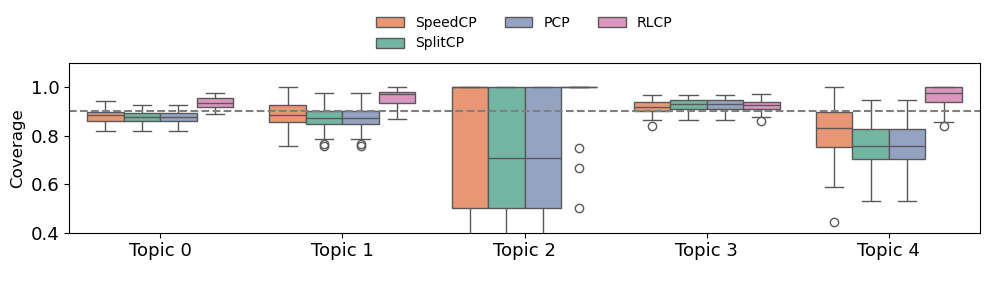

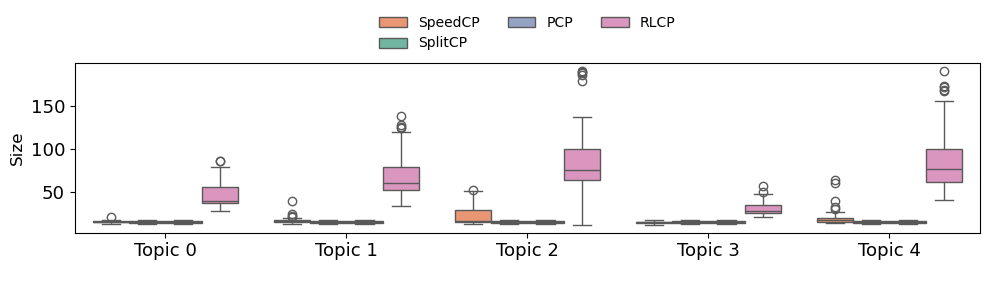

In [29]:
method_names = list(METHODS.keys())
original_palette = sns.color_palette("Set2", n_colors=len(method_names))

reddest_index = max(range(len(original_palette)), key=lambda i: original_palette[i][0])

swapped_palette = original_palette.copy()
swapped_palette[0], swapped_palette[reddest_index] = swapped_palette[reddest_index], swapped_palette[0]
palette = dict(zip(method_names, swapped_palette))

# Create a dataframe for plotting coverage and cutoffs
coverage_data = []
for method in METHODS.keys():
    for c in range(K):
        cover_vals = cover_by_cluster[method][c]
        cutoff_vals = cut_by_cluster[method][c]
        for val in cover_vals:
            coverage_data.append({
                "method": method,
                "shift_type": f"Topic {c}",
                "type": "Coverage",
                "value": val
            })
        for val in cutoff_vals:
            coverage_data.append({
                "method": method,
                "shift_type": f"Topic {c}",
                "type": "Size",
                "value": val
            })
# Create a single plot
fig, ax = plt.subplots(figsize=(10, 3))

coverage_df = pd.DataFrame(coverage_data)
coverage_df["shift_type"] = coverage_df["shift_type"].astype(str)

# Create boxplot
sns.boxplot(data=coverage_df[coverage_df['shift_type'].str.startswith('Topic') & (coverage_df['type'] == 'Coverage')], 
            x="shift_type", y="value", hue="method", 
            palette=palette, ax=ax)
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
)
ax.set_ylim(0.4, 1.1)
ax.axhline(0.9, color='gray', linestyle='--', label="target miscoverage")
ax.set_xlabel(" ")
ax.set_ylabel("Coverage", fontsize = 12)
plt.xticks(rotation=0)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)
plt.tight_layout()

fig, ax = plt.subplots(figsize=(10, 3))
sns.boxplot(data=coverage_df[coverage_df['shift_type'].str.startswith('Topic') & (coverage_df['type'] == 'Size')], 
            x="shift_type", y="value", hue="method", 
            palette=palette, ax=ax)
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
)
#ax.set_ylim(0.4, 1.1)
ax.set_xlabel(" ")
ax.set_ylabel("Size", fontsize = 12)
plt.xticks(rotation=0)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)
plt.tight_layout()

In [32]:
mean_df = (
    coverage_df
    .groupby(["method", "shift_type", "type"])["value"]
    .mean()
    .reset_index()
)

sd_df = (
    coverage_df
    .groupby(["method", "shift_type", "type"])["value"]
    .std(ddof=1)
    .reset_index()
)

coverage_means = mean_df[mean_df["type"] == "Coverage"]
print("\nCoverage Means:")
print(coverage_means.pivot(index="shift_type", columns="method", values="value"))

coverage_sds = sd_df[sd_df["type"] == "Coverage"]
print("\nCoverage Standard Deviations:")
print(coverage_sds.pivot(index="shift_type", columns="method", values="value"))

size_means = mean_df[mean_df["type"] == "Size"]
print("\nSize Means:")
print(size_means.pivot(index="shift_type", columns="method", values="value"))


Coverage Means:
method           PCP      RLCP   SpeedCP   SplitCP
shift_type                                        
Topic 0     0.877114  0.935329  0.880974  0.877114
Topic 1     0.876002  0.958005  0.890009  0.876002
Topic 2     0.659375  0.956597  0.730556  0.659375
Topic 3     0.926991  0.923368  0.920104  0.926991
Topic 4     0.762664  0.962352  0.822426  0.762664

Coverage Standard Deviations:
method           PCP      RLCP   SpeedCP   SplitCP
shift_type                                        
Topic 0     0.024612  0.022196  0.027283  0.024612
Topic 1     0.046155  0.035426  0.056645  0.046155
Topic 2     0.350378  0.168421  0.345100  0.350378
Topic 3     0.024938  0.023690  0.027158  0.024938
Topic 4     0.088887  0.043988  0.114106  0.088887

Size Means:
method            PCP       RLCP    SpeedCP    SplitCP
shift_type                                            
Topic 0     15.661654  47.182950  15.990890  15.661434
Topic 1     15.661654  69.740088  17.239292  15.661434
Topic